<a href="https://colab.research.google.com/github/Deepanshu8285/qwert/blob/main/CIFAR10Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential,load_model
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout,BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau,EarlyStopping,ModelCheckpoint




In [ ]:
(X_train,Y_train),(X_test,Y_test)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2682s 16us/step


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print("Drive exists:", os.path.exists("/content/drive"))
print("MyDrive exists:", os.path.exists("/content/drive/MyDrive"))

Drive exists: True
MyDrive exists: True


In [ ]:
import numpy as np

np.save('/content/drive/MyDrive/CIFAR10/X_train.npy', X_train)
np.save('/content/drive/MyDrive/CIFAR10/Y_train.npy', Y_train)
np.save('/content/drive/MyDrive/CIFAR10/X_test.npy', X_test)
np.save('/content/drive/MyDrive/CIFAR10/Y_test.npy', Y_test)

print("Saved successfully!")

Saved successfully!


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/CIFAR10'))

['X_train.npy', 'X_test.npy', 'Y_test.npy', 'Y_train.npy']


In [ ]:
print(os.listdir('/content/drive/MyDrive/CIFAR10'))

['X_train.npy', 'X_test.npy', 'Y_test.npy', 'Y_train.npy']


In [5]:
import numpy as np

X_train = np.load('/content/drive/MyDrive/CIFAR10/X_train.npy')
Y_train = np.load('/content/drive/MyDrive/CIFAR10/Y_train.npy')

X_test = np.load('/content/drive/MyDrive/CIFAR10/X_test.npy')
Y_test = np.load('/content/drive/MyDrive/CIFAR10/Y_test.npy')

print("Loaded Successfully!")
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

Loaded Successfully!
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [6]:
X_train,X_valid,Y_train,Y_valid=train_test_split(X_train,Y_train,test_size=0.1,random_state=10)
class_names=[
    'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
]
X_train.shape
# X_test.shape
# X_valid.shape

(45000, 32, 32, 3)

In [7]:
X_test.shape

(10000, 32, 32, 3)

In [8]:
X_valid.shape

(5000, 32, 32, 3)

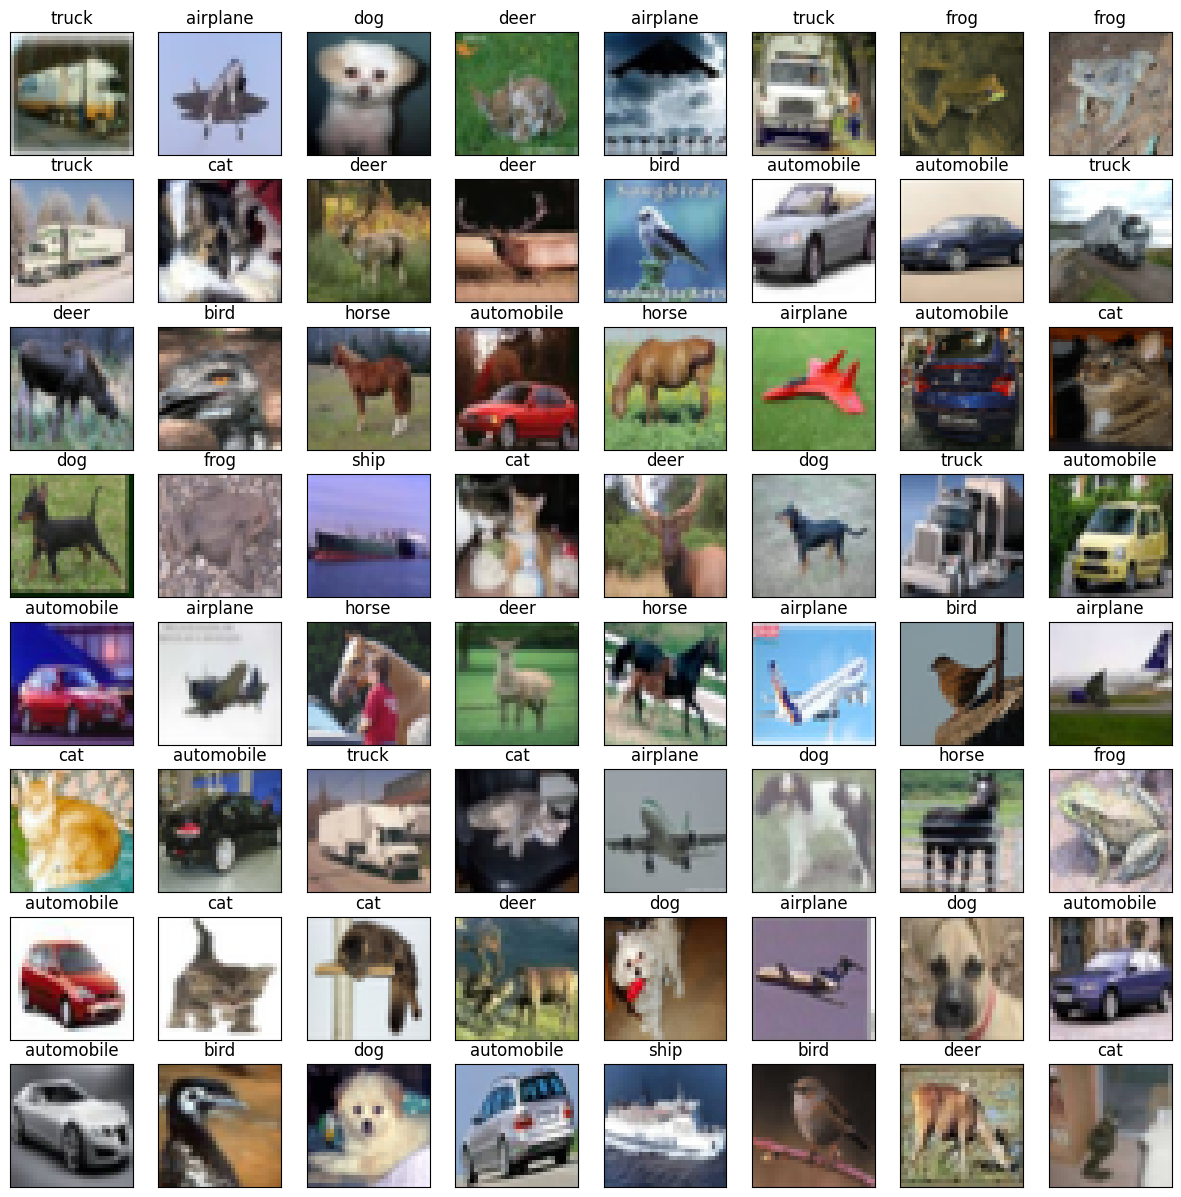

In [9]:
plt.figure(figsize=(15,15))
for i in range(64):
  plt.subplot(8,8,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(X_train[i])
  plt.title(class_names[Y_train[i][0]])

plt.show()


##DATA PREPROCESSING


*   Normalisation of images
*   One hot encoding of labels


*   Data Augmentation





##Normalisation

In [10]:
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_valid=X_valid.astype('float32')
mean=np.mean(X_train)
std=np.std(X_train)
X_train=(X_train-mean)/(std+0.000000001)
X_test=(X_test-mean)/(std+0.000000001)
X_valid=(X_valid-mean)/(std+0.000000001)


##One Hot Encoding of Labels

In [11]:
Y_train=to_categorical(Y_train,10)
Y_test=to_categorical(Y_test,10)
Y_valid=to_categorical(Y_valid,10)



In [12]:
X_train.shape

(45000, 32, 32, 3)

In [13]:
Y_train.shape

(45000, 10)

##Data Augmentation

In [14]:
data_generator=ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9,1.1],
    shear_range=10,
    channel_shift_range=0.1

)

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/CIFAR10_Model', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Model Architecture

In [16]:
model=Sequential()
weight_decay=0.0001
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same',
    kernel_regularizer=l2(weight_decay),
    input_shape=X_train.shape[1:]

))
model.add(BatchNormalization())


model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same',
    kernel_regularizer=l2(weight_decay)


))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(rate=0.2))
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu',
    padding='same',
    kernel_regularizer=l2(weight_decay)

))
model.add(BatchNormalization())


model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu',
    padding='same',
    kernel_regularizer=l2(weight_decay)

))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(rate=0.3))
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu',
    padding='same',
    kernel_regularizer=l2(weight_decay)

))
model.add(BatchNormalization())


model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu',
    padding='same',
    kernel_regularizer=l2(weight_decay)

))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(rate=0.4))





model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(10,activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,57

 Total params: 815,914 (3.11 MB)

 Trainable params: 815,018 (3.11 MB)

 Non-trainable params: 896 (3.50 KB)

In [67]:
model = load_model("/content/drive/MyDrive/CIFAR10/best_model.keras")

In [32]:
batch_size=64
epochs=50
optimizer=Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,loss='categorical_crossentropy',metrics=['accuracy'])
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=10,min_lr=0.00001)
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True,
    verbose=1

)
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/CIFAR10/best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

model.fit(data_generator.flow(X_train,Y_train,batch_size=batch_size),
                              epochs=epochs,
                              validation_data=(X_valid,Y_valid),
                              callbacks=[reduce_lr,early_stopping,checkpoint],

                              )

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8571 - loss: 0.5226
Epoch 1: val_loss improved from None to 0.51118, saving model to /content/drive/MyDrive/CIFAR10/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CIFAR10/best_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 87ms/step - accuracy: 0.8584 - loss: 0.5200 - val_accuracy: 0.8714 - val_loss: 0.5112 - learning_rate: 5.0000e-04
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8606 - loss: 0.5124
Epoch 2: val_loss improved from 0.51118 to 0.51052, saving model to /content/drive/MyDrive/CIFAR10/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CIFAR10/best_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.8574 - loss: 0.5207 - val_accuracy: 0.8666 - val_loss: 0.5105 - learning_rate: 5.0000e-04
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8590 - loss: 0.5251
Epoch 3: val_loss did not improve from 0.51052
704

In [ ]:
!nvidia-smi

Tue Jul 28 05:34:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             32W /   70W |     655MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive/CIFAR10/best_model.keras'))

True


##Visualising the Learning Curves

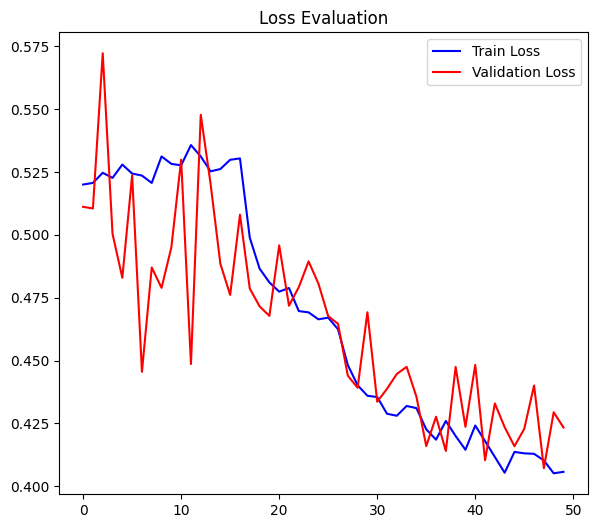

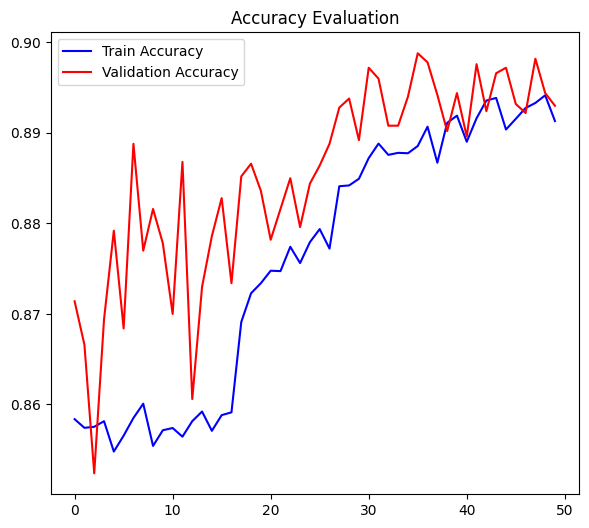

In [33]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.plot(model.history.history['loss'],label='Train Loss',color='blue')
plt.plot(model.history.history['val_loss'],label='Validation Loss',color='red')
plt.legend()
plt.title('Loss Evaluation')

plt.figure(figsize=(15,6))
plt.subplot(1,2,2)
plt.plot(model.history.history['accuracy'],label='Train Accuracy',color='blue')
plt.plot(model.history.history['val_accuracy'],label='Validation Accuracy',color='red')
plt.legend()
plt.title('Accuracy Evaluation')
plt.show()

##Evaluating the Optimal Model on Test Data

In [34]:
test_loss,test_acc=model.evaluate(X_test,Y_test,verbose=1)
print(f'Test Accuracy : {test_acc}\nTest Loss :{test_loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8957 - loss: 0.4172
Test Accuracy : 0.8956999778747559
Test Loss :0.4172474145889282


In [21]:
url='https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg'
reps=urllib.request.urlopen(url)
image=np.asarray(bytearray(reps.read()),dtype='uint8')
image=cv2.imdecode(image,cv2.IMREAD_UNCHANGED)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)


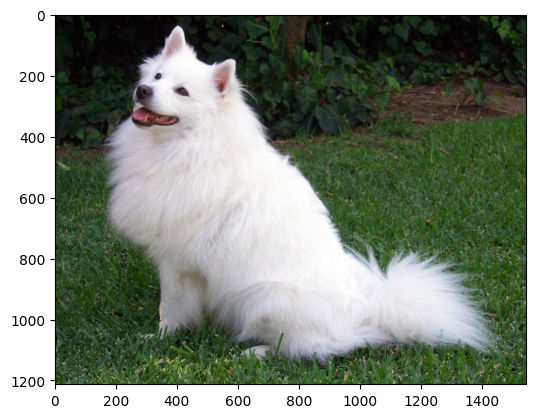

In [22]:
plt.imshow(image)
plt.show()

In [23]:
image.shape

(1213, 1546, 3)

In [24]:
image=cv2.resize(image,(32,32))
image=(image-mean)/(std+0.00001)
image=image.reshape((1,32,32,3))

In [25]:
predict=model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [34]:
predict

array([[1.4741983e-05, 1.5593494e-05, 3.4821328e-02, 6.7744710e-02,
        1.7906739e-04, 8.7373495e-01, 2.3086123e-02, 1.8829400e-04,
        2.1328511e-04, 1.8554279e-06]], dtype=float32)

In [35]:
class_names[predict.argmax()]

'dog'

In [80]:
X_test[0]

array([[[ 0.58196604, -0.13535795, -1.11778   ],
        [ 0.59756005, -0.15095195, -1.148968  ],
        [ 0.6911241 , -0.07298195, -1.086592  ],
        ...,
        [ 0.25449204, -0.40045595, -1.3205019 ],
        [ 0.08295805, -0.46283194, -1.3205019 ],
        [-0.07298195, -0.55639595, -1.3672839 ]],

       [[ 0.48840207, -0.13535795, -1.086592  ],
        [ 0.47280806, -0.16654594, -1.2581259 ],
        [ 0.59756005, -0.10416995, -1.180156  ],
        ...,
        [ 0.23889805, -0.40045595, -1.398472  ],
        [ 0.06736405, -0.46283194, -1.382878  ],
        [-0.02619995, -0.50961393, -1.3516899 ]],

       [[ 0.47280806, -0.16654594, -1.148968  ],
        [ 0.47280806, -0.18213995, -1.3672839 ],
        [ 0.58196604, -0.15095195, -1.3205019 ],
        ...,
        [ 0.28568006, -0.35367396, -1.3516899 ],
        [ 0.14533405, -0.40045595, -1.3516899 ],
        [-0.01060595, -0.49401996, -1.3672839 ]],

       ...,

       [[-0.821494  ,  0.05177005,  0.8782521 ],
        [-1

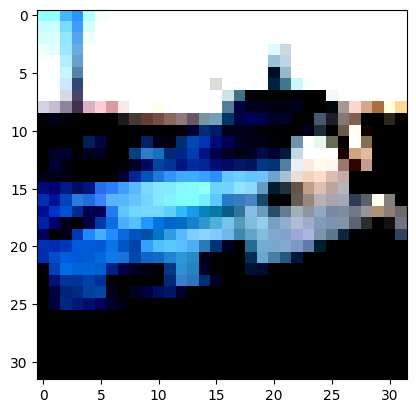

In [82]:
plt.imshow(X_test[2])

In [84]:
predict=model.predict(X_test[2].reshape((1,32,32,3)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [85]:
class_names[predict.argmax()]

'ship'

In [89]:
class_names[Y_test[2].argmax()]

'ship'

In [91]:
correct = 0
for i in range(len(X_test)):
  label = class_names[model.predict(X_test[i].reshape((1,32,32,3))).argmax()]
  actual = class_names[Y_test[i].argmax()]
  if(label==actual): correct+=1
correct

Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

8957

In [97]:
Y_test.shape

(10000, 10)

In [98]:
correct/100

89.57